# CCO06: Change cell type number of clusters

In [3]:
import scanpy as sc
import matplotlib.pyplot as plt
import glob
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata
import os
import glob
import scipy

In [4]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06

In [16]:
PREV_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO05"
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO06"

## 1. Relabel cell type according to Jun's label

In [10]:
%%bash

mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/cell_type_labelled

mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/dotplots

In [11]:
%%bash
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__ALL-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/ALL.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__BHO-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/VHO.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__BVO-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/VO.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__CM3B-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/VCO.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__CM3O-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/CA.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__HO-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/HO.h5ad

/tmp/ipykernel_1226053/195061385.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pat.obs['leiden'][0] = j
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/tmp/ipykernel_1226053/195061385.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pat.obs['leiden'][0] = j
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/annd

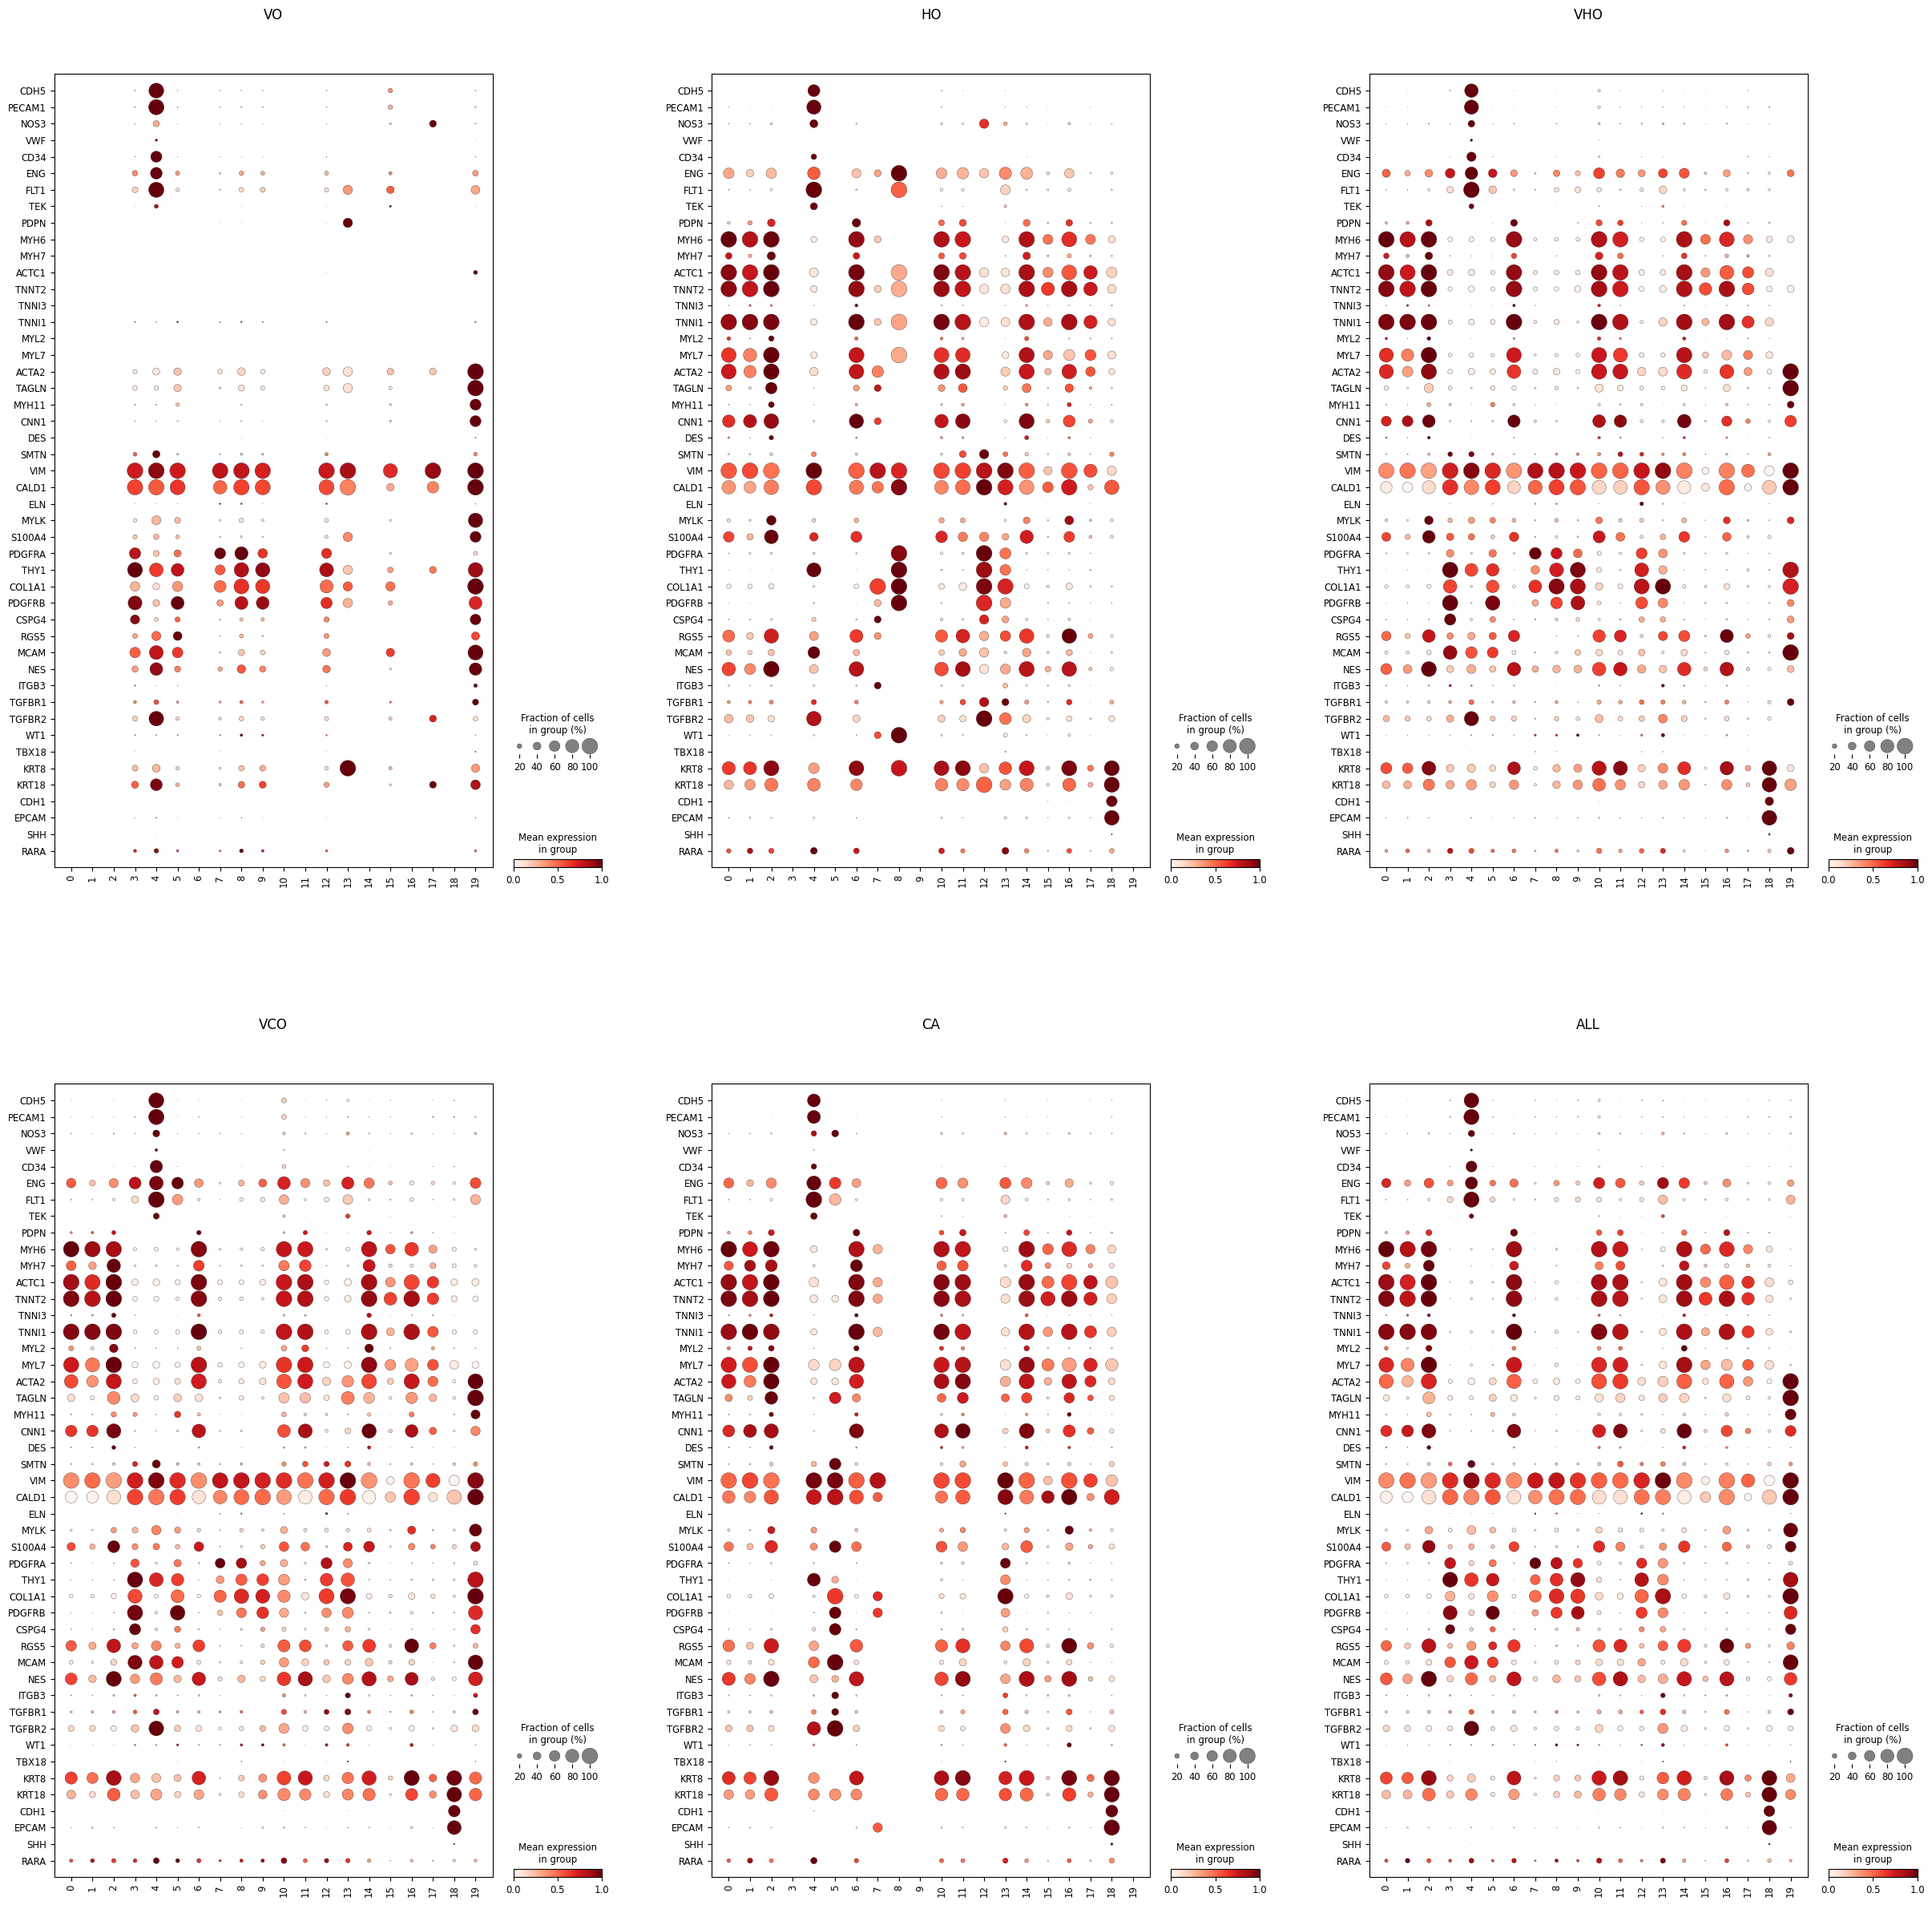

In [15]:
marker_dict = ['CDH5', 'PECAM1', 'NOS3', 'VWF', 'CD34', 'ENG', 'FLT1', 'TEK', 'PDPN', 'MYH6', 
               'MYH7', 'ACTC1', 'TNNT2', 'TNNI3', 'TNNI1', 'MYL2', 'MYL7', 'ACTA2', 'TAGLN', 'MYH11', 
               'CNN1', 'DES', 'SMTN', 'VIM', 'CALD1', 'ELN', 'MYLK', 'S100A4', 'PDGFRA', 'THY1', 
               'COL1A1', 'PDGFRB', 'CSPG4', 'RGS5', 'MCAM', 'NES', 'ITGB3', 'TGFBR1', 'TGFBR2', 'WT1', 
               'TBX18', 'KRT8', 'KRT18', 'CDH1', 'EPCAM', 'SHH', 'RARA']

fig, axs = plt.subplots(2, 3, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i, d1 in enumerate(glob.glob(f'{WORK_DIR}/adata/leiden_clustered/*.h5ad')):
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(d1)
    
    adata.obs['leiden'] = adata.obs['leiden'].astype("int")
    for j in range(0, 20):
        if (adata.obs['leiden'] == j).any():
            continue
        else:
            pat = adata[0].copy()
            pat.obs['leiden'][0] = j
            pat.X.data[:] = 0
            adata = adata.concatenate(pat, batch_key='batch')
    adata.obs['leiden'] = adata.obs['leiden'].astype("category")
    
    sc.pl.dotplot(adata, marker_dict, groupby="leiden", standard_scale="var", ax=axs[i], title=sample_name, show=False, swap_axes=True)
    
plt.savefig(f'{WORK_DIR}/dotplots/dotplot_leiden.png')
plt.show()

In [55]:
samples = ['ALL','VO','HO','CA','VHO','VCO']
samples_old = ['ALL','BVO','HO','CM3O','BHO','CM3B']

celltypes_dict = {
    '0': 'CM', 
    '1': 'CM',
    '2': 'CM',
    '3': 'PR',
    '4': 'EN',
    '5': 'PR',
    '6': 'CM',
    '7': 'FB',
    '8': 'FB',
    '9': 'FB',
    '10': 'CM',
    '11': 'CM',
    '12': 'FB',
    '13': 'SM',
    '14': 'CM',
    '15': 'UN',
    '16': 'CM',
    '17': 'UN',
    '18': 'EP',
    '19': 'SM',
}

In [56]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/uamps

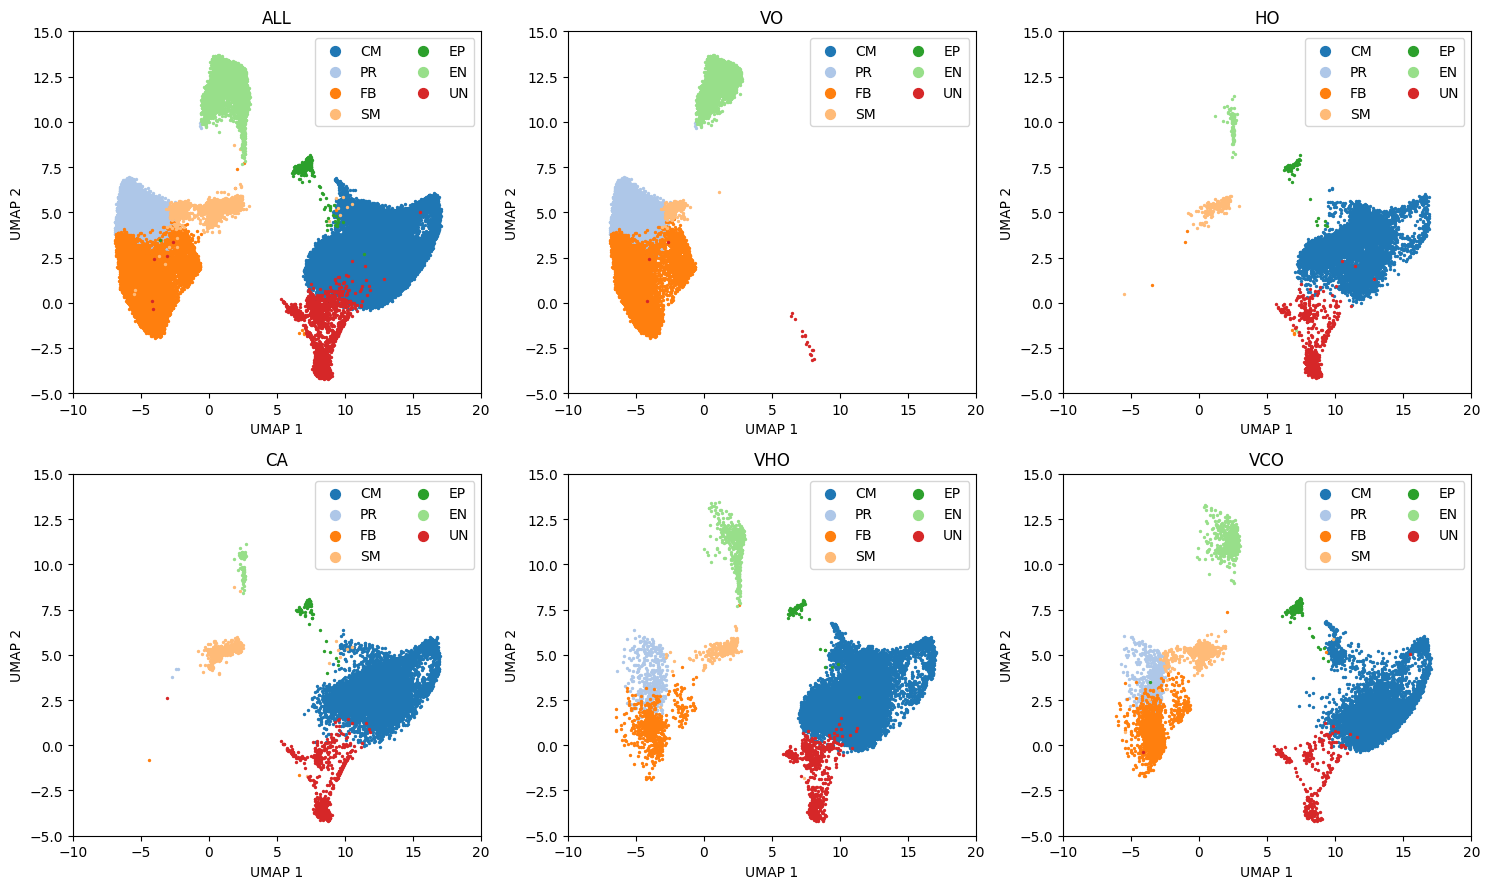

In [58]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

cell_types = ['CM','PR','FB','SM','EP','EN','UN']
cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab20').colors

batch_mapper = dict(zip(samples_old, samples))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/leiden_clustered/{sample}.h5ad')
    adata.obs['cell_type'] = adata.obs['leiden'].map(celltypes_dict)
    
    adata.obs['batch'] = adata.obs['batch'].astype('str')
    adata.obs['batch'] = adata.obs['batch'].map(batch_mapper)
    adata.obs['batch'] = adata.obs['batch'].astype('category')
    
    adata.write(f'{WORK_DIR}/adata/cell_type_labelled/{sample}.h5ad')
    
    for j, ct in enumerate(cell_types):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 1], 
            label=ct, 
            color=colors[j], s=2)
        
    axs[i].legend(loc='upper right', markerscale=5, ncol=2)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-10, 20])
    axs[i].set_ylim([-5, 15])
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/cell_type_labelled.png')
plt.show()

## 2. Split cell types and recluster

In [59]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/cell_type_split
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/cell_type_subclustered

In [60]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
for ct in cell_types:
    adata = adata_all[adata_all.obs['cell_type'] == ct]
    adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")

### 2.1 Cardiomyocytes - aim for 4 clusters

In [61]:
ct = "CM"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=0.3)
adata.obs['leiden']

AAACCCAAGAAGGGAT-1-0    0
AAACCCAAGTCAGGGT-1-0    1
AAACCCACATCCAACA-1-0    1
AAACCCAGTAGATGTA-1-0    1
AAACCCAGTAGTACGG-1-0    1
                       ..
TTTGTTGAGACTGGGT-1-4    1
TTTGTTGAGATTGACA-1-4    0
TTTGTTGAGGGTACGT-1-4    0
TTTGTTGTCATGCCGG-1-4    2
TTTGTTGTCGTTGCCT-1-4    2
Name: leiden, Length: 25615, dtype: category
Categories (4, object): ['0', '1', '2', '3']

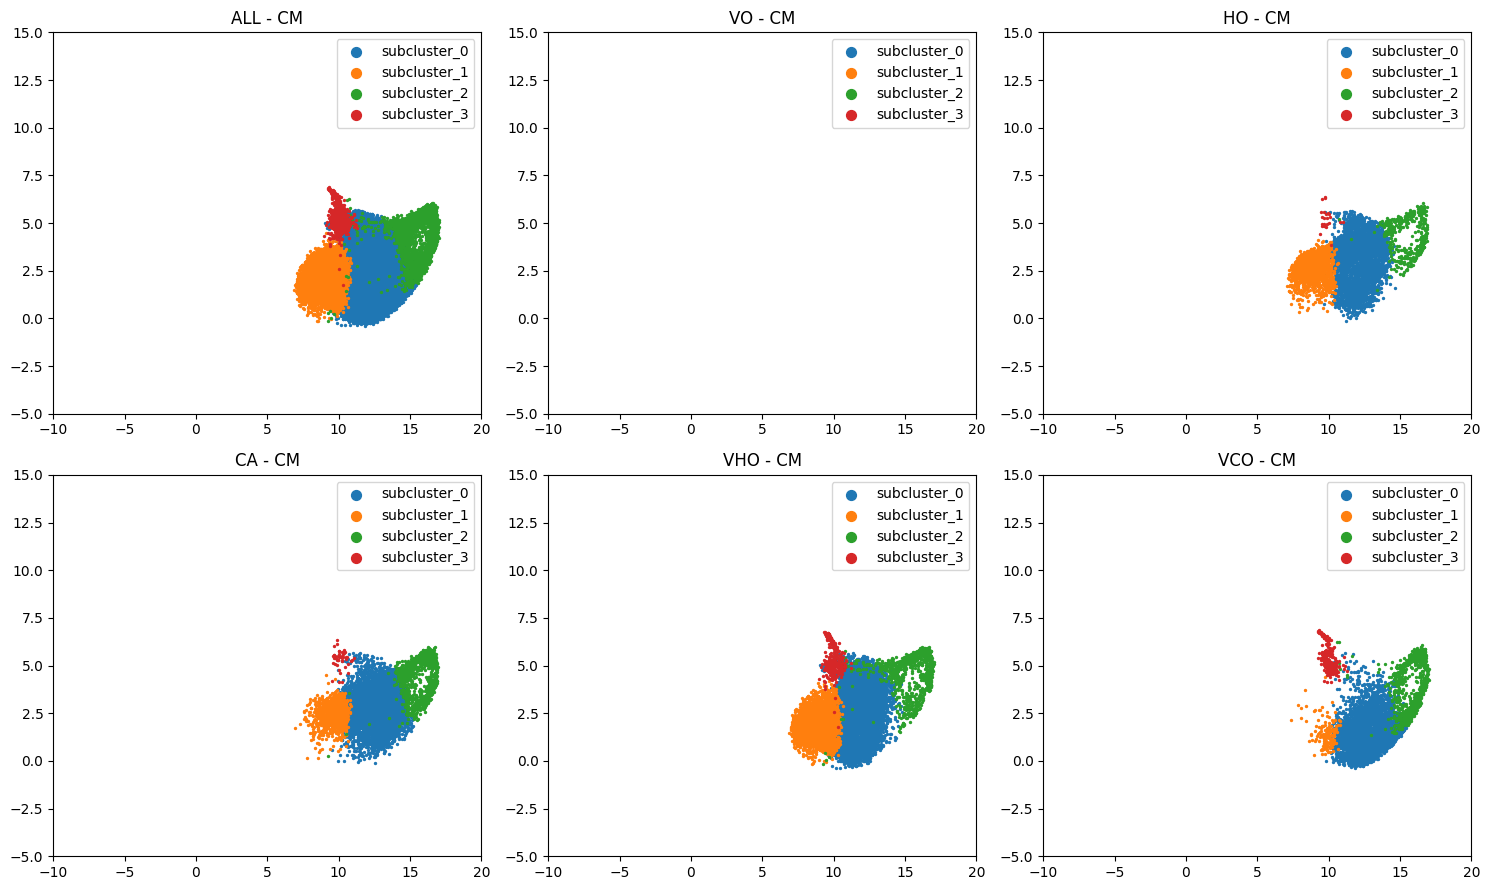

In [62]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, 4):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"subcluster_{i}", s=2)
    
    ax.set_xlim([-10, 20])
    ax.set_ylim([-5, 15])
    ax.legend(loc='upper right', markerscale=5)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/subclusters_{ct}.png')
plt.show()

In [63]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')
adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

### 2.2 Fibroblast

In [64]:
ct = "FB"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=0.1)
adata.obs['leiden']

AAACCCATCATTGCGA-1-0    0
AAAGGATAGCGCCTAC-1-0    0
AAAGGGCTCTCGGTAA-1-0    0
AAAGGTAGTCCACAGC-1-0    1
AAAGTGATCTCATAGG-1-0    0
                       ..
CAGGGCTCAAGCACAG-1-4    0
CCTCATGGTCTGTGGC-1-4    0
CGCATAATCATTGCCC-1-4    1
CTCCTCCAGTCCTGTA-1-4    0
TCTACATAGGTTATAG-1-4    0
Name: leiden, Length: 9742, dtype: category
Categories (2, object): ['0', '1']

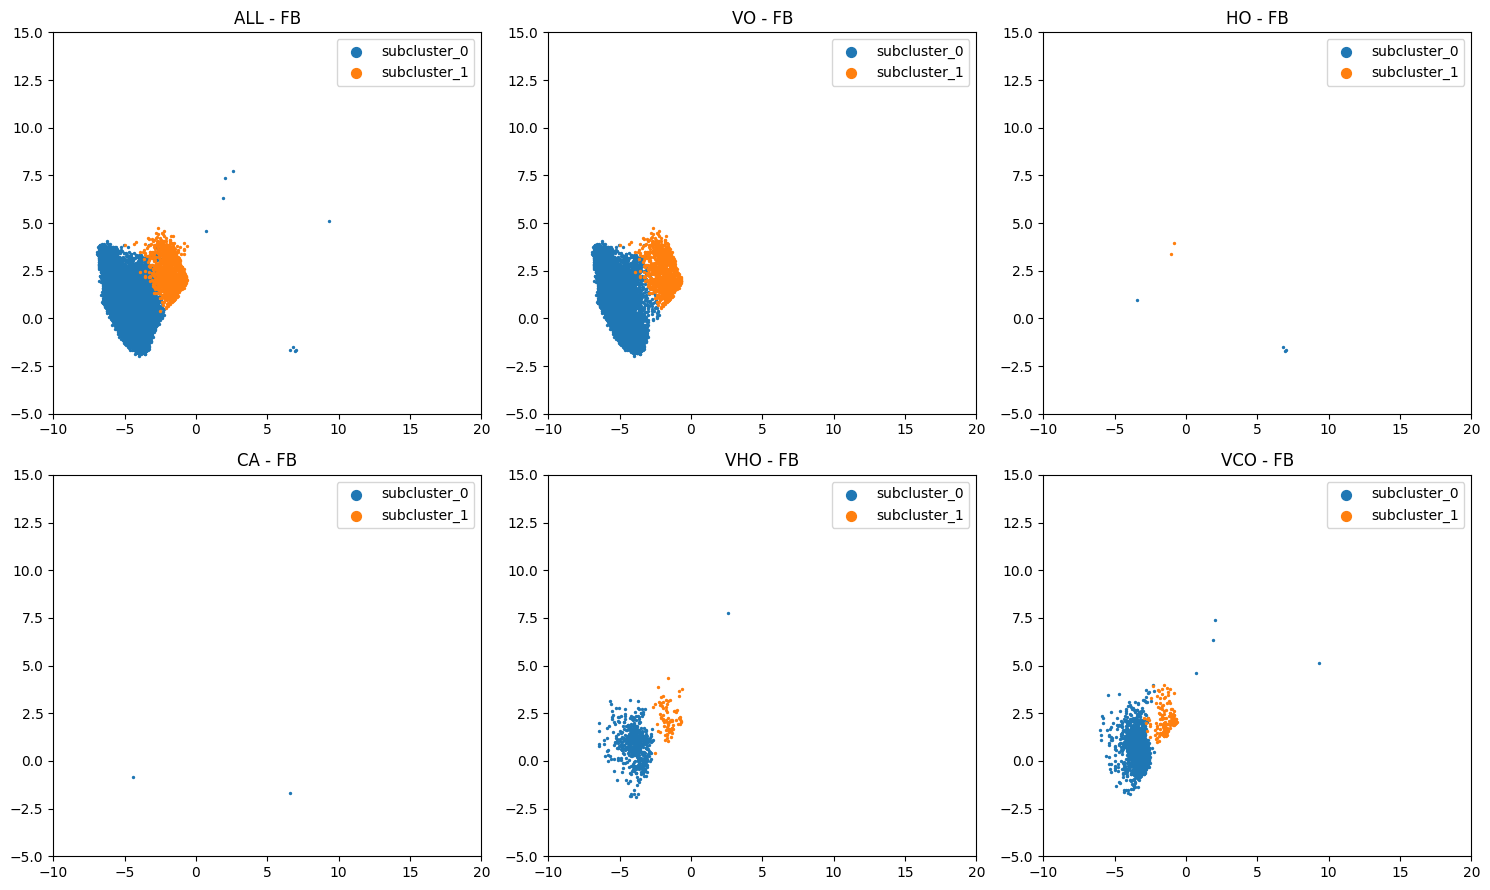

In [65]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, 2):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"subcluster_{i}", s=2)
    
    ax.set_xlim([-10, 20])
    ax.set_ylim([-5, 15])
    ax.legend(loc='upper right', markerscale=5)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/subclusters_{ct}.png')
plt.show()

In [66]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')
adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

### 2.3 endothelial cells

In [70]:
ct = "EN"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=0.15)
adata.obs['leiden']

AAACCCACATCCTTGC-1-0    0
AAAGAACAGGGCAATC-1-0    0
AAAGGATGTCAAGCGA-1-0    0
AAAGGGCCAGCGTATT-1-0    0
AAATGGAAGCTGCCAC-1-0    1
                       ..
TTAGGCAGTGTGTCGC-1-4    0
TTCGCTGCAAGTGGGT-1-4    0
TTTACTGGTAGACACG-1-4    0
TTTCAGTAGCGCTGAA-1-4    0
TTTGATCAGCGCACAA-1-4    0
Name: leiden, Length: 4175, dtype: category
Categories (2, object): ['0', '1']

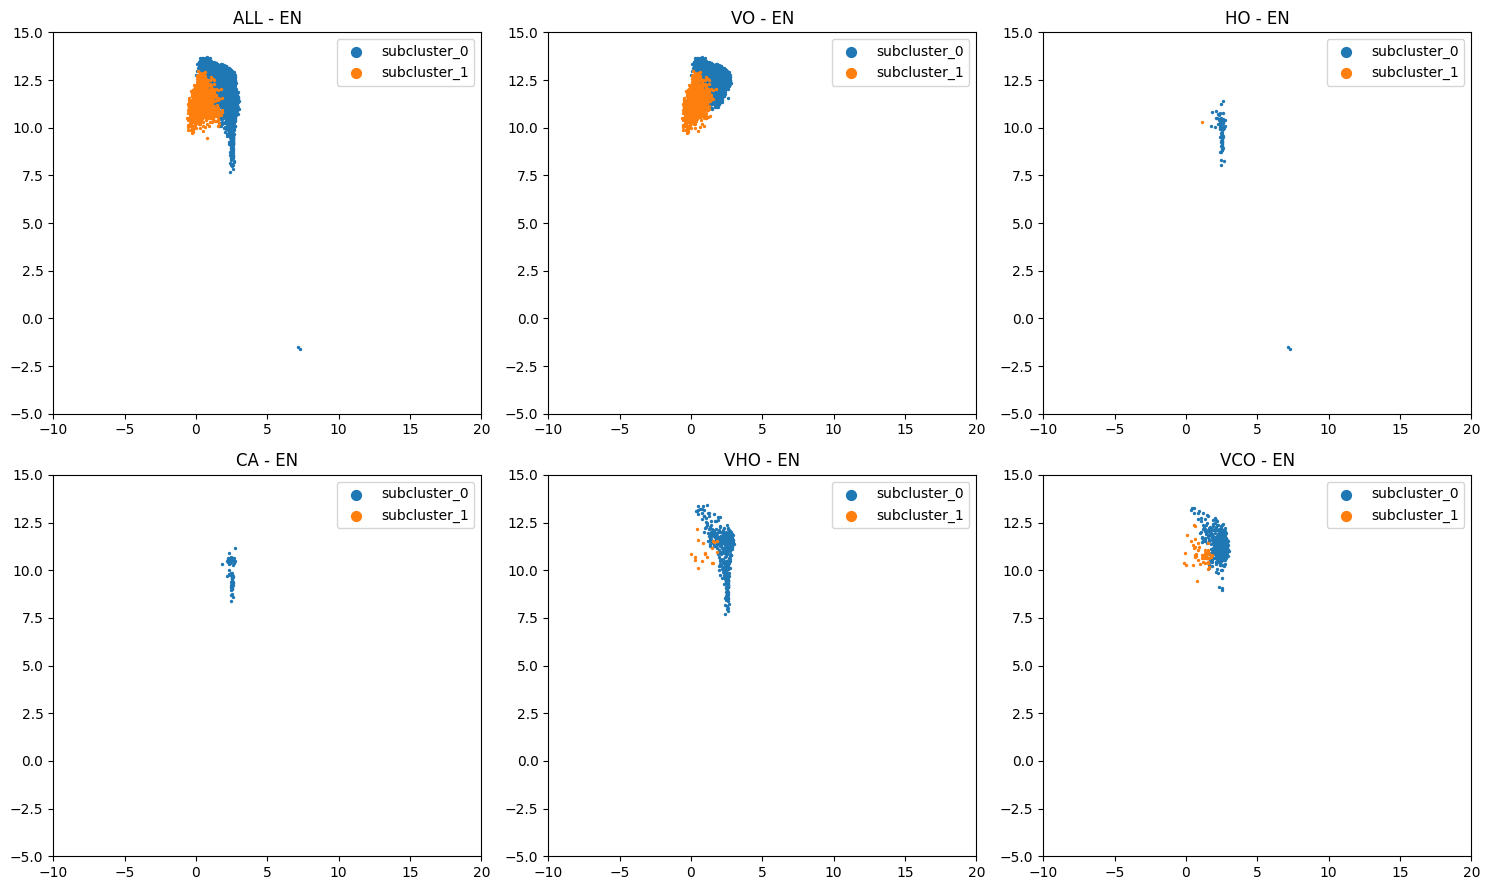

In [71]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, 2):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"subcluster_{i}", s=2)
    
    ax.set_xlim([-10, 20])
    ax.set_ylim([-5, 15])
    ax.legend(loc='upper right', markerscale=5)
    ax.set_title(f"{sample} - {ct}")

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/subclusters_{ct}.png')
plt.show()

In [72]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')
adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

### 2.4 don't subcluster other celltypes for now

In [89]:
cts = ['PR','SM','EP','UN']

for ct in cts:
    adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
    adata.obs['cell_type_subcluster'] = adata.obs['cell_type'].copy()
    adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

### 2.5 rearrange according to experiment

In [108]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/sample_recollect

In [111]:
for sample in ['ALL','VO','HO','CA','VHO','VCO']:
    for ct in ['CM','PR','FB','SM','EP','EN','UN']:
        
        adata_ct = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
        
        if sample == 'ALL':
            adata_ct_sample = adata_ct
        else:
            adata_ct_sample = adata_ct[adata_ct.obs['batch'] == sample]

        if ct == 'CM':
            adata_sample = adata_ct_sample
        else:
            adata_sample = ad.concat([adata_sample, adata_ct_sample], join='inner', axis=0)
            
    adata_sample.write_h5ad(f"{WORK_DIR}/adata/sample_recollect/{sample}.h5ad")

In [117]:
cell_type_subcluster = ['CM_0', 'CM_1', 'CM_2',  'CM_3', 'FB_0', 'FB_1', 'EN_0', 'EN_1', 'PR', 'SM', 'EP', 'UN']

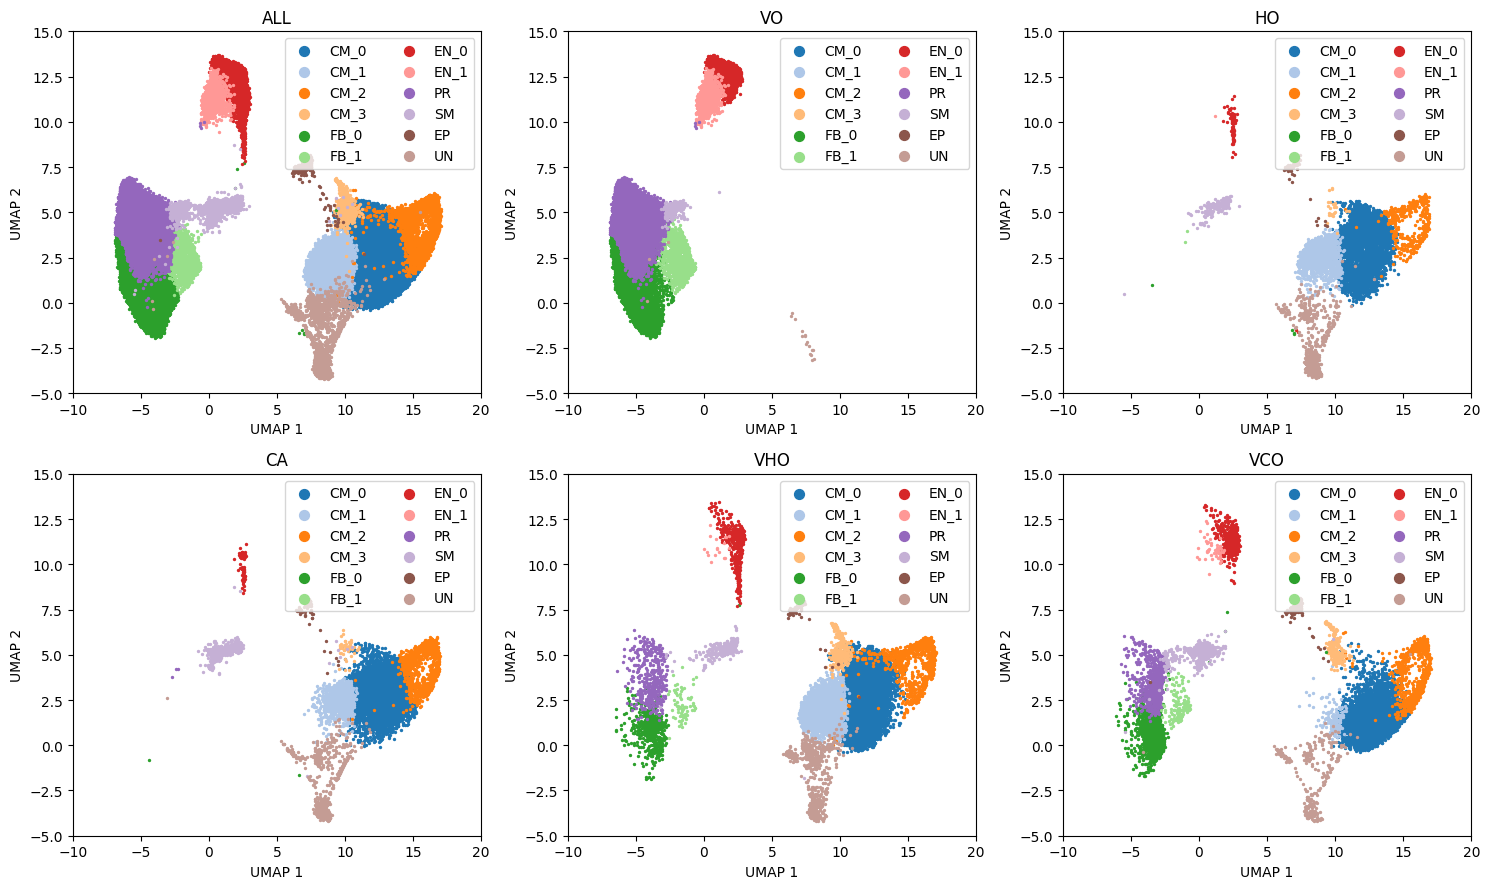

In [118]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab20').colors

batch_mapper = dict(zip(samples_old, samples))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/{sample}.h5ad')
    
    for j, cts in enumerate(cell_type_subcluster):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 1], 
            label=cts, 
            color=colors[j], s=2)
        
    axs[i].legend(loc='upper right', markerscale=5, ncol=2)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-10, 20])
    axs[i].set_ylim([-5, 15])
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/sample_recollect.png')
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: N

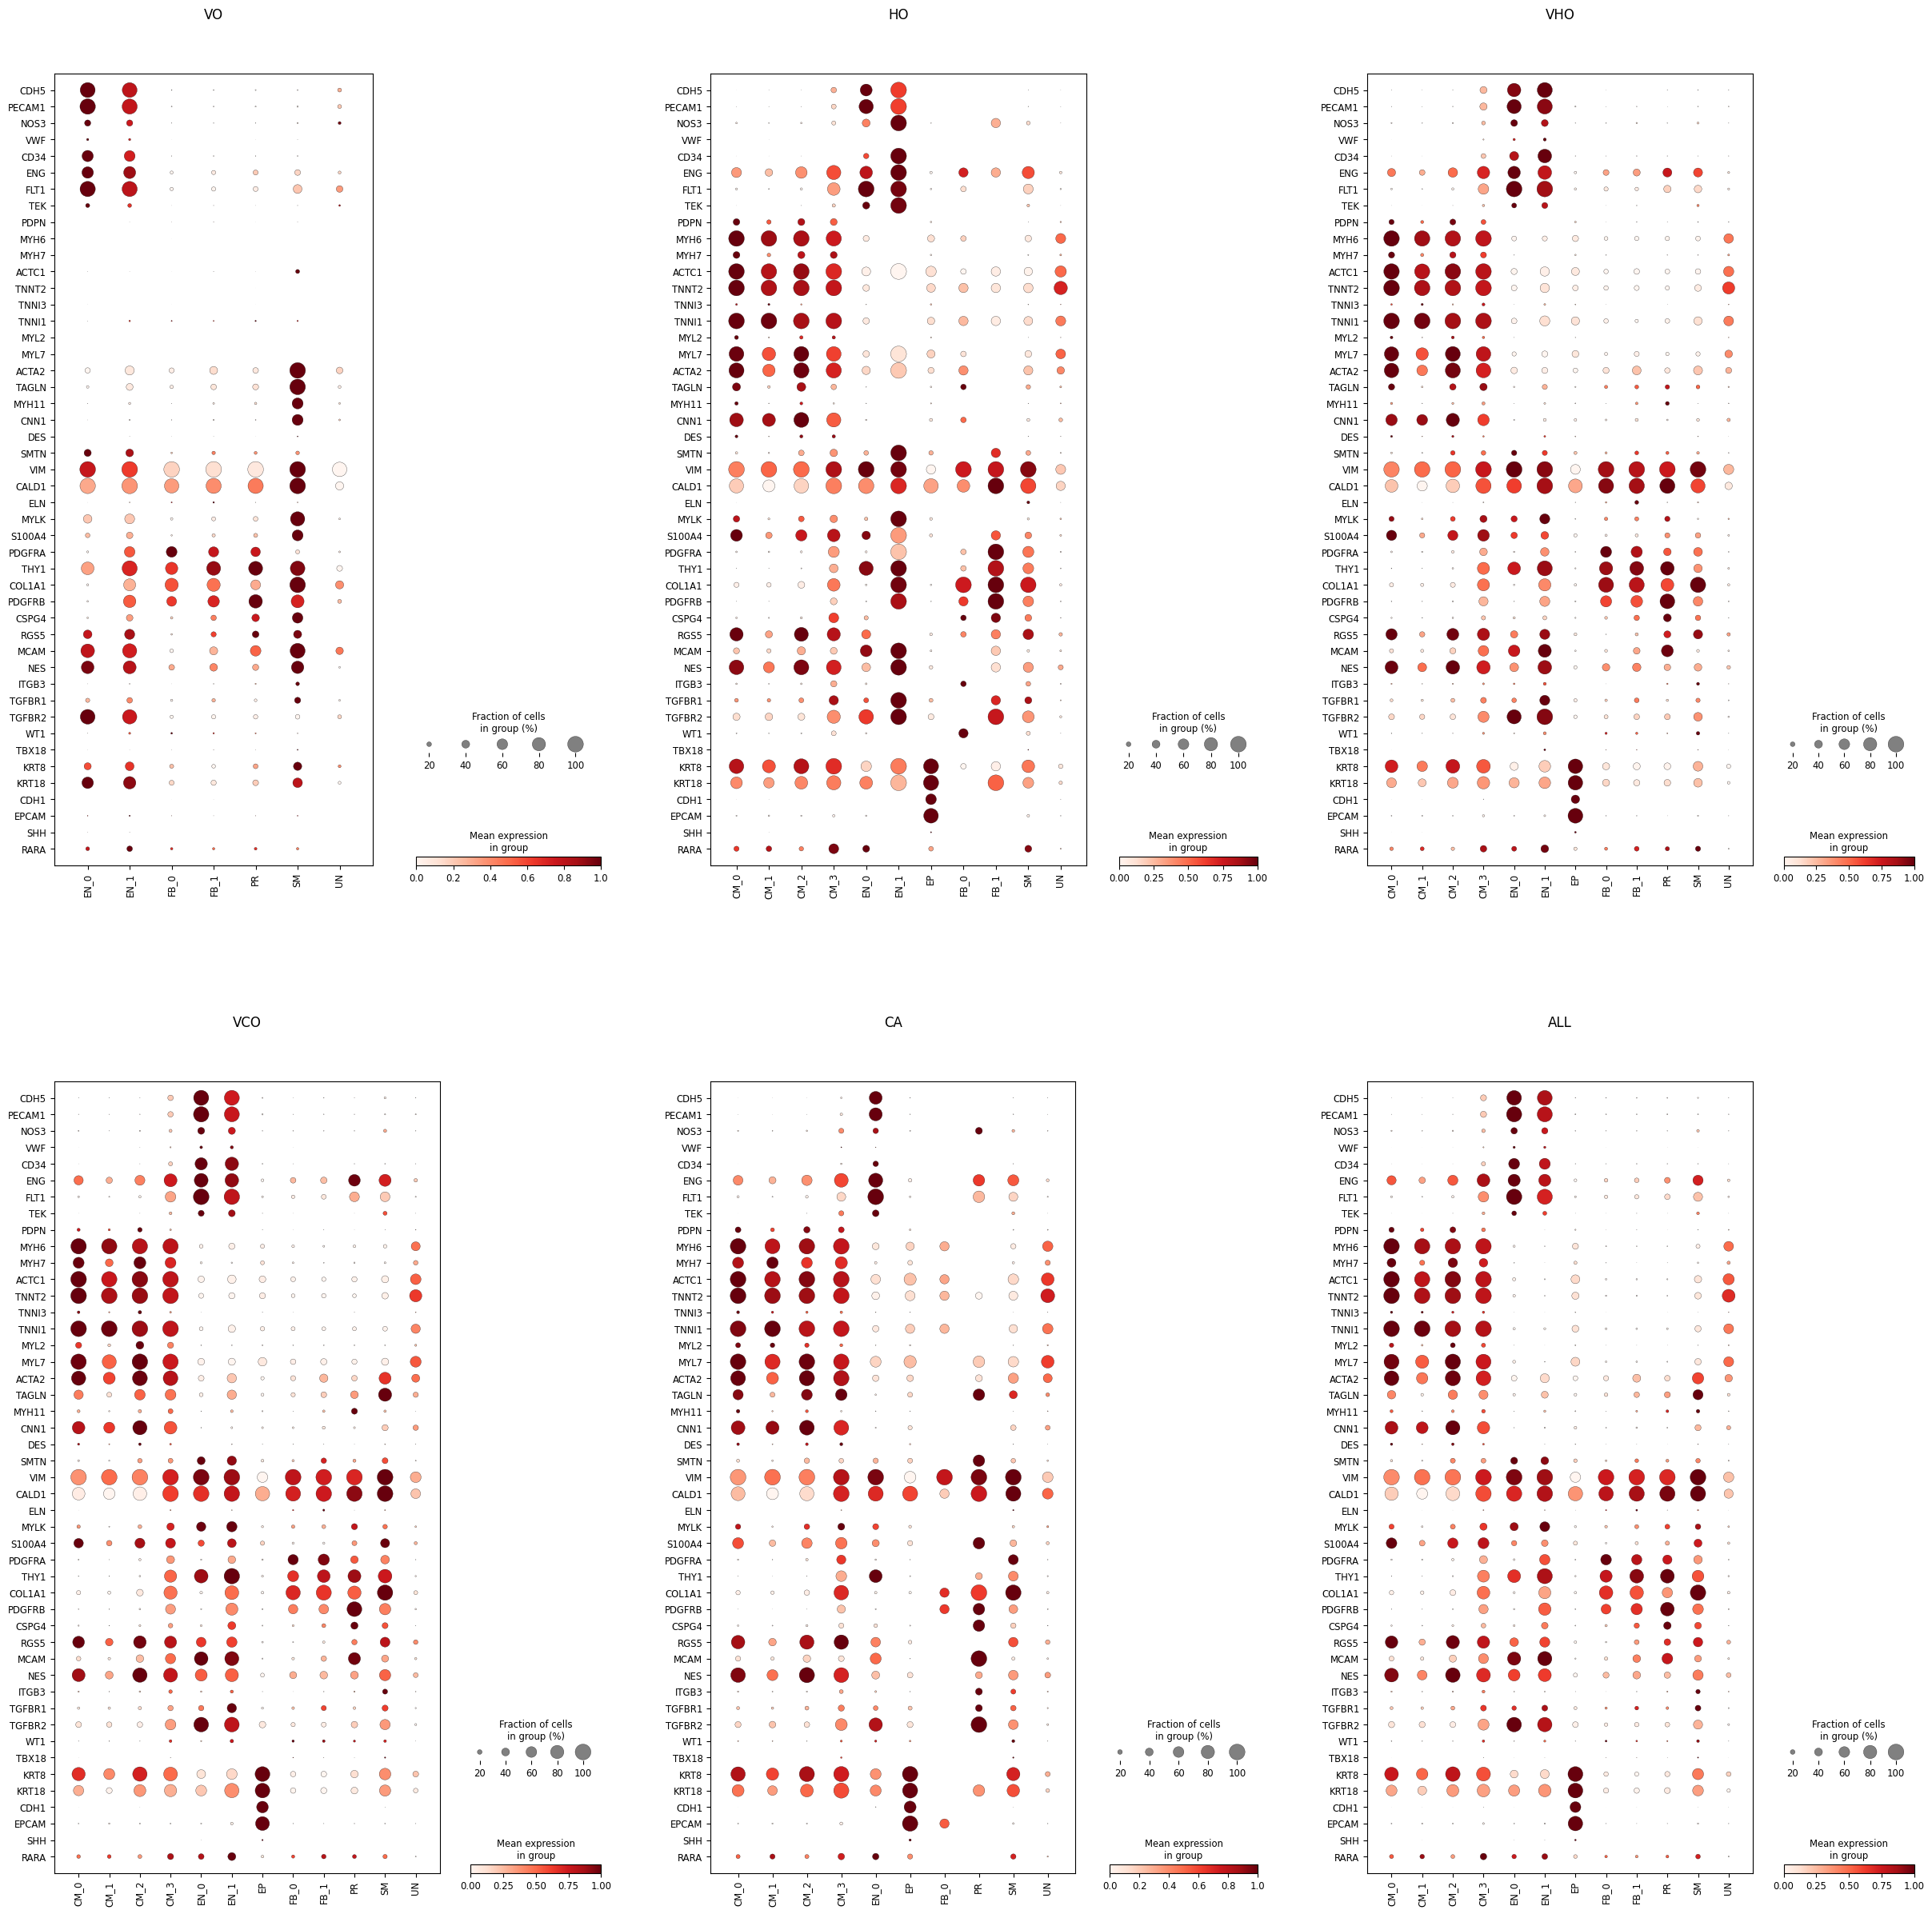

In [8]:
marker_dict = ['CDH5', 'PECAM1', 'NOS3', 'VWF', 'CD34', 'ENG', 'FLT1', 'TEK', 'PDPN', 'MYH6', 
               'MYH7', 'ACTC1', 'TNNT2', 'TNNI3', 'TNNI1', 'MYL2', 'MYL7', 'ACTA2', 'TAGLN', 'MYH11', 
               'CNN1', 'DES', 'SMTN', 'VIM', 'CALD1', 'ELN', 'MYLK', 'S100A4', 'PDGFRA', 'THY1', 
               'COL1A1', 'PDGFRB', 'CSPG4', 'RGS5', 'MCAM', 'NES', 'ITGB3', 'TGFBR1', 'TGFBR2', 'WT1', 
               'TBX18', 'KRT8', 'KRT18', 'CDH1', 'EPCAM', 'SHH', 'RARA']

fig, axs = plt.subplots(2, 3, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i, d1 in enumerate(glob.glob(f'{WORK_DIR}/adata/sample_recollect/*.h5ad')):
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(d1)
    sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", ax=axs[i], title=sample_name, show=False, swap_axes=True)
    
plt.savefig(f'{WORK_DIR}/dotplots/dotplot_celltype_subcluster.png')
plt.show()

## 3. DE between samples

In [42]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano

In [6]:
adata_BVO = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/VO.h5ad')
adata_HO = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/HO.h5ad')
adata_CM3O = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/CA.h5ad')
adata_BHO = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/VHO.h5ad')
adata_CM3B = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/VCO.h5ad')

adatas = {'HO': adata_HO, 'VO': adata_BVO, 'CA': adata_CM3O, 'VHO': adata_BHO, 'VCO': adata_CM3B}

In [30]:
def volcano_plot(adata1, adata2, celltype, title, keygenes=None, save=None, save_tsv=None):
    
    fc_thres = 1.5
    pvalue_thres = 5
    
    if np.any(adata1.var_names != adata2.var_names):
        raise ValueError('adata var names not unified')
    
    PSEUDOCOUNT=0.001
    data1 = adata1.X[adata1.obs['cell_type'] == celltype, :].todense().copy() + PSEUDOCOUNT
    data2 = adata2.X[adata2.obs['cell_type'] == celltype, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene)
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
    plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

In [10]:
def volcano_plot2(adata1, celltype_subcluster1, celltype_subcluster2, title, keygenes=None, save=None, save_tsv=None):
    
    fc_thres = 1.5
    pvalue_thres = 5
    
    PSEUDOCOUNT=0.001
    data1 = adata1.X[adata1.obs['cell_type_subcluster'] == celltype_subcluster1, :].todense().copy() + PSEUDOCOUNT
    data2 = adata1.X[adata1.obs['cell_type_subcluster'] == celltype_subcluster2, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene)
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
    plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

### 3.1 Cardiomyocyte

In [43]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/CM

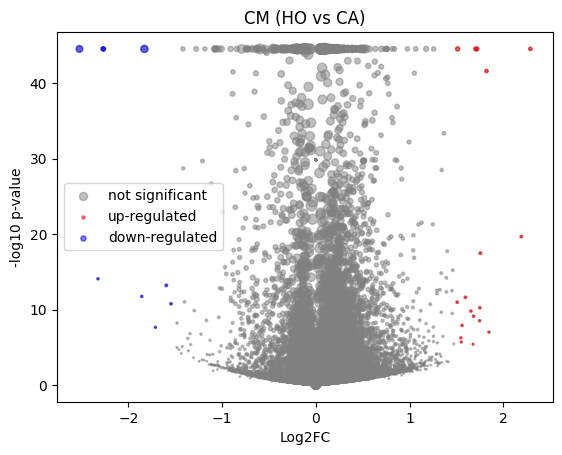

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


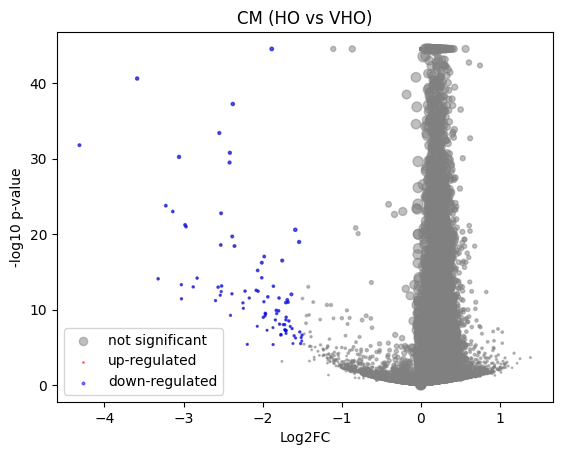

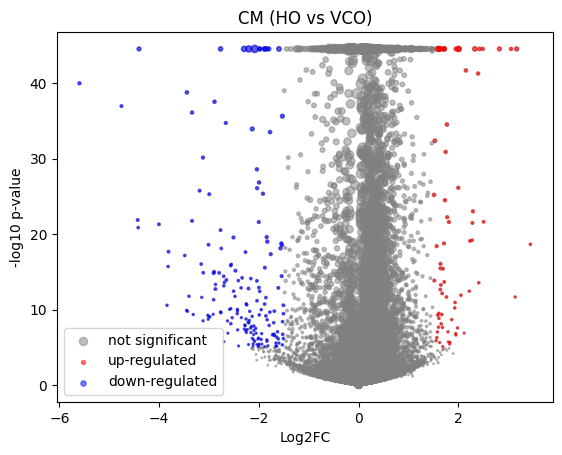

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


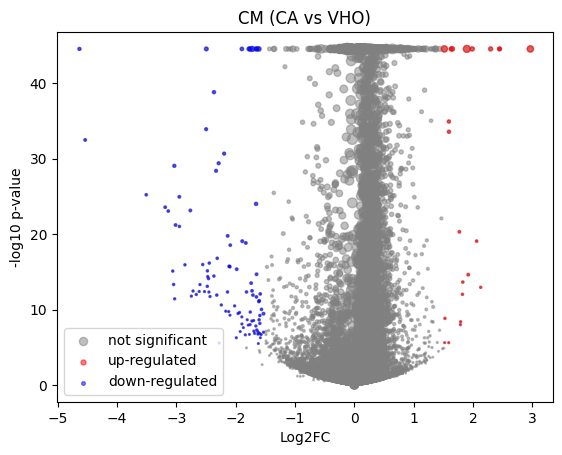

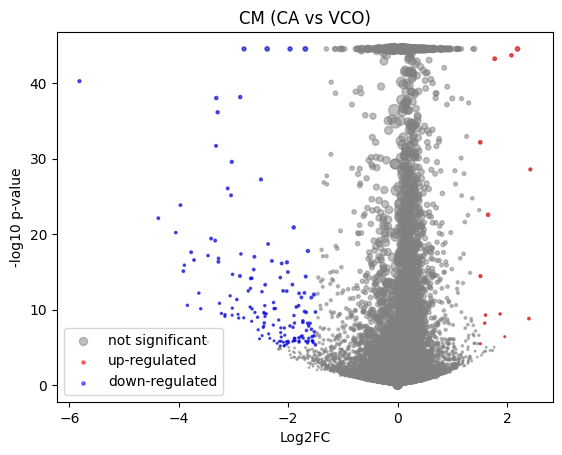

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


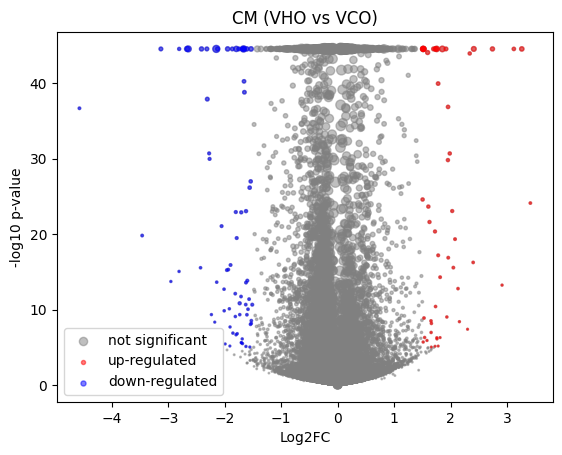

In [44]:
celltype = 'CM'
adata_list = ['HO', 'CA', 'VHO', 'VCO']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

### 3.2 Endothelial cell

In [45]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/EN

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


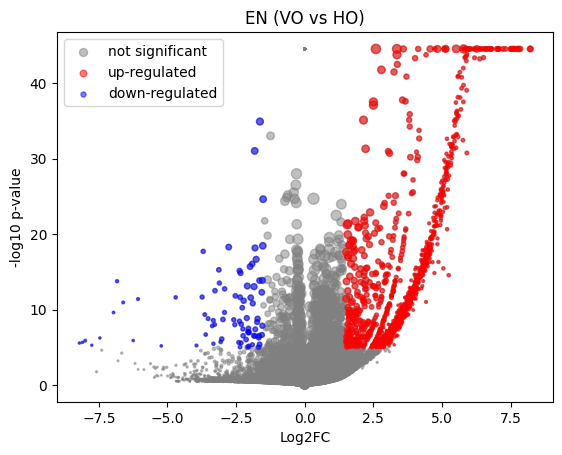

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


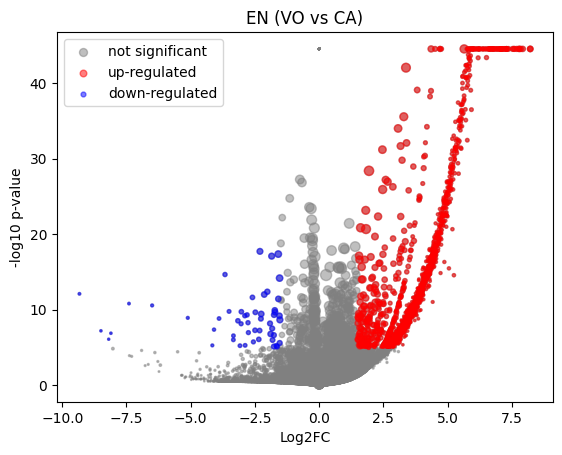

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


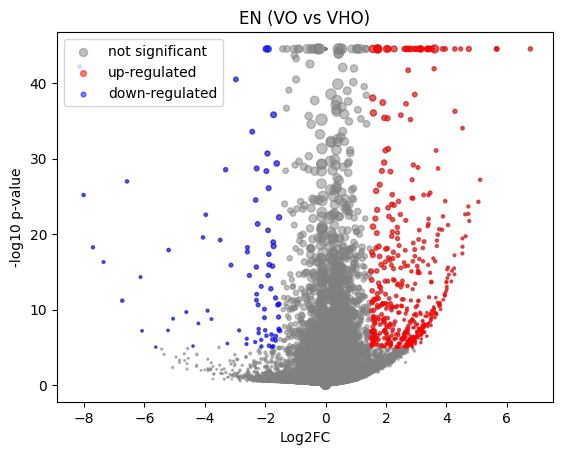

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


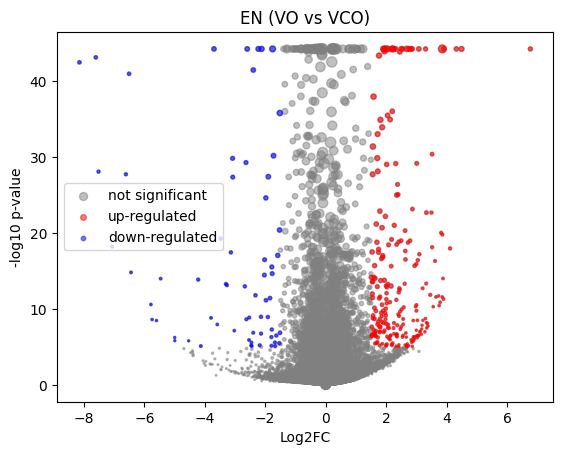

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


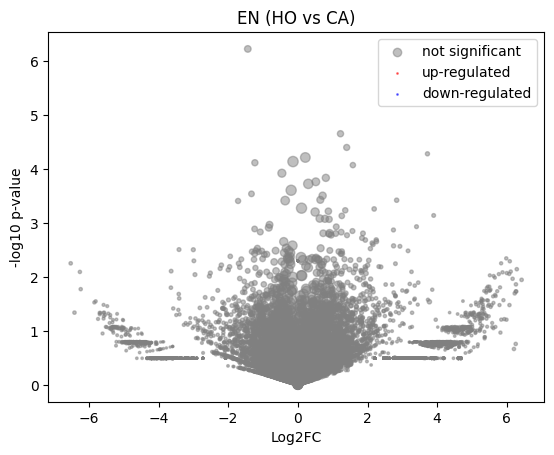

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


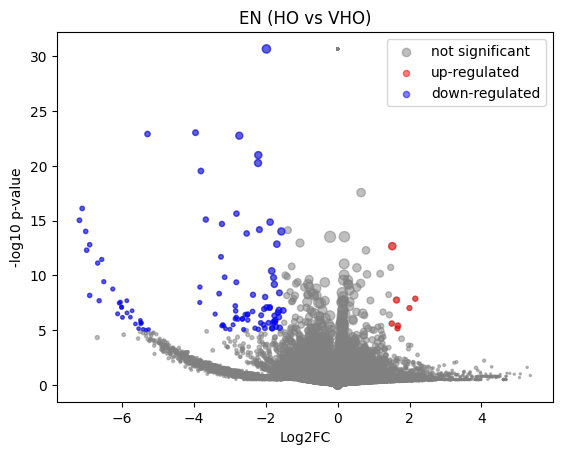

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


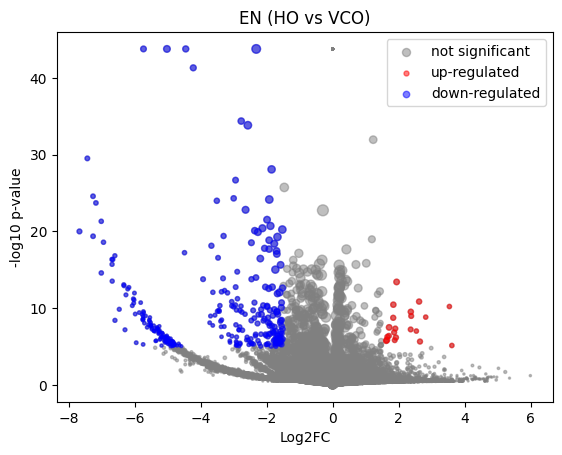

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


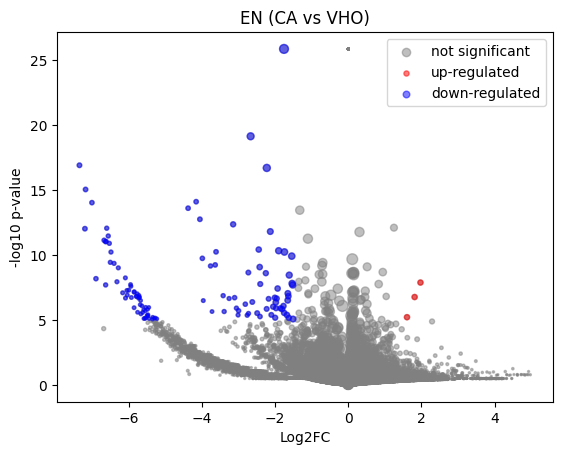

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


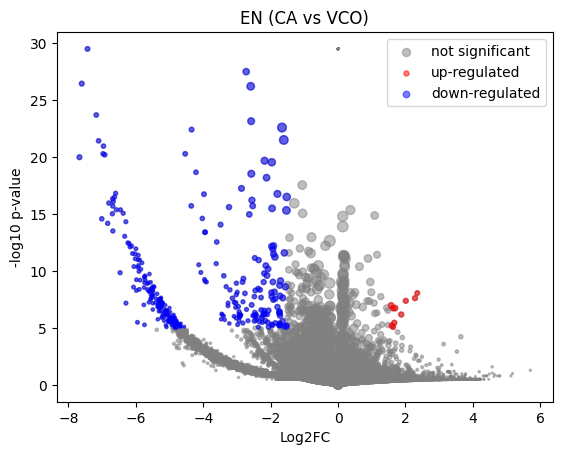

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


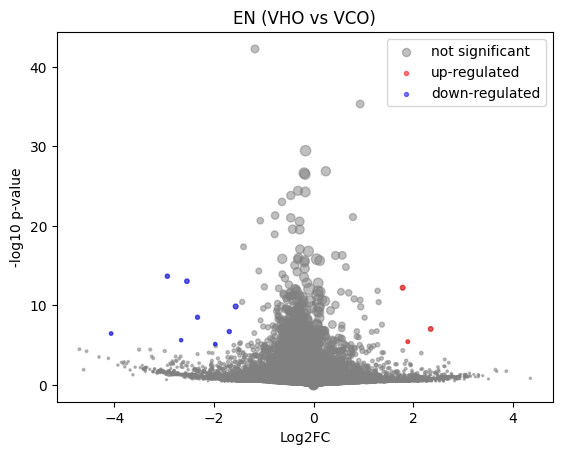

In [46]:
celltype = 'EN'
adata_list = ['VO', 'HO', 'CA', 'VHO', 'VCO']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

### 3.3 Fibroblast

In [47]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/FB

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


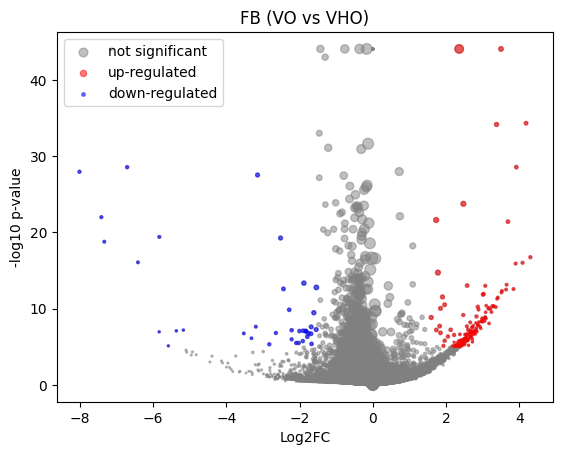

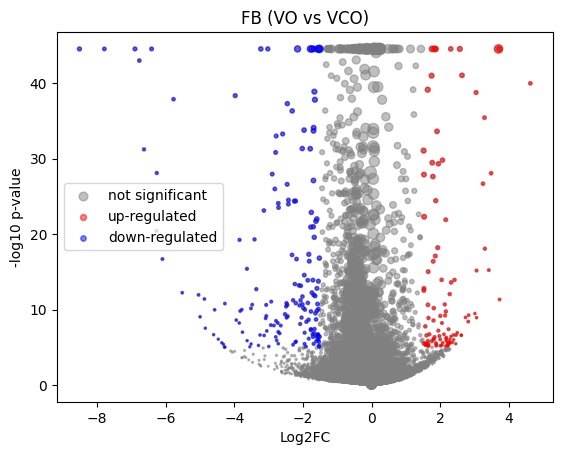

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


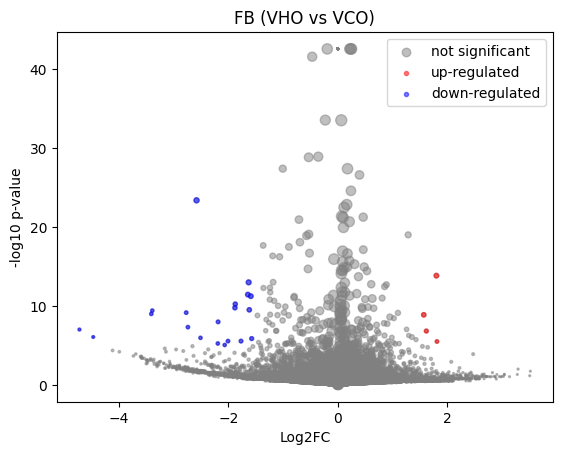

In [48]:
celltype = 'FB'
adata_list = ['VO', 'VHO', 'VCO']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

### 3.4 Epithelial

In [49]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/EP

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


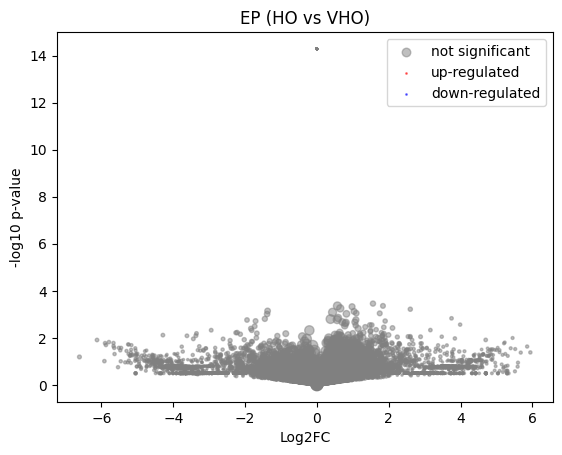

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


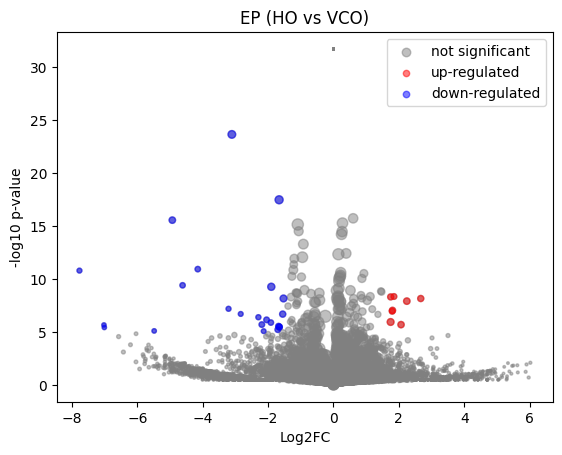

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


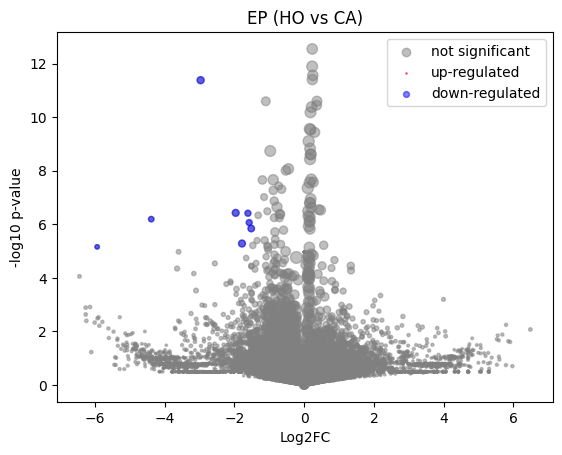

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


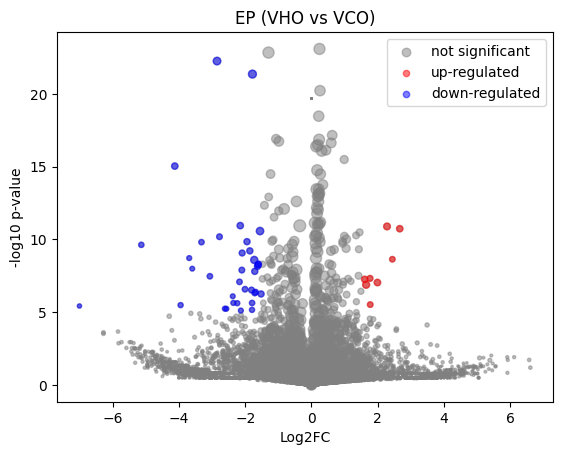

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


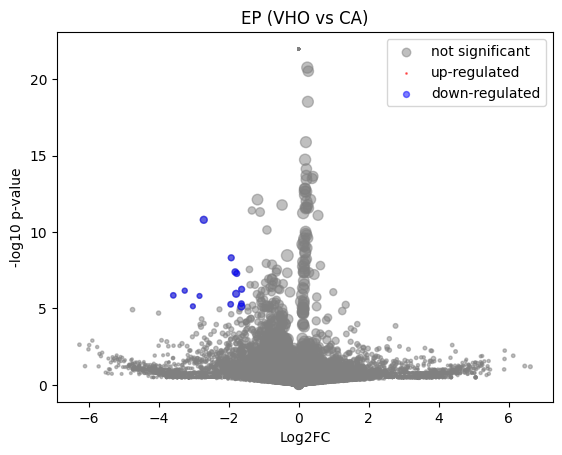

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


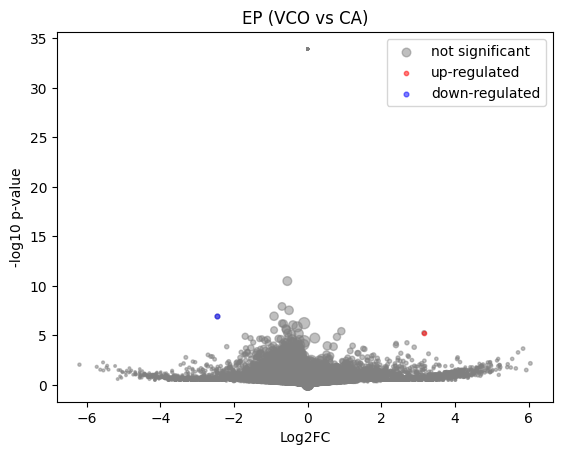

In [50]:
celltype = 'EP'
adata_list = ['HO', 'VHO', 'VCO', 'CA']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

### 3.5 Smooth muscle cell

In [51]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/SM

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


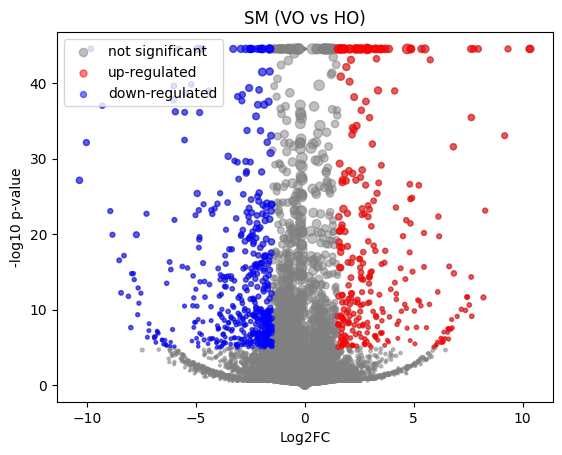

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


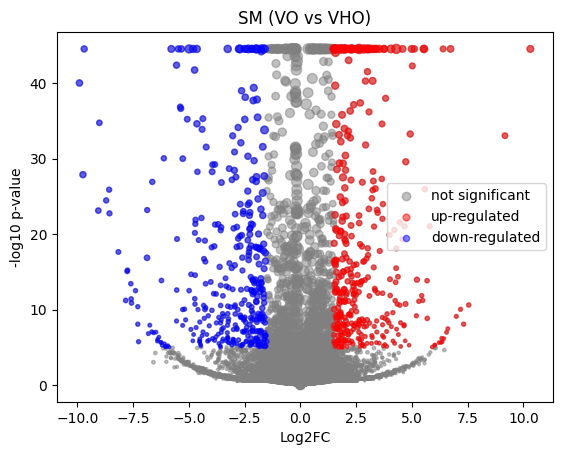

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


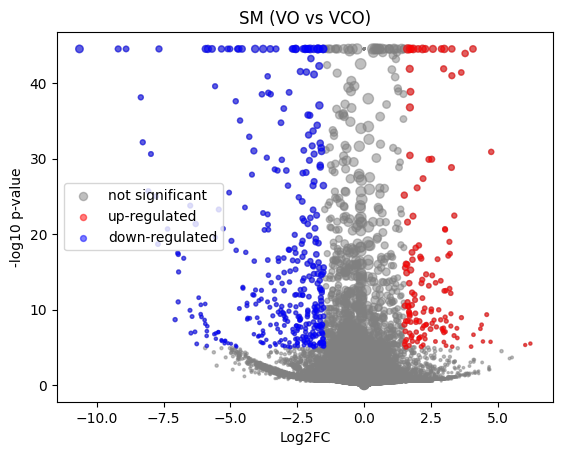

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


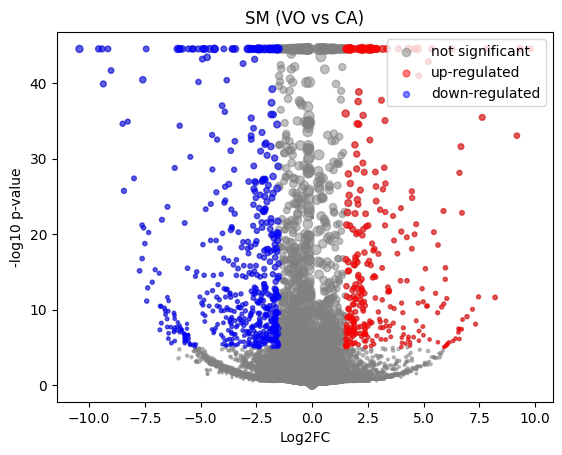

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


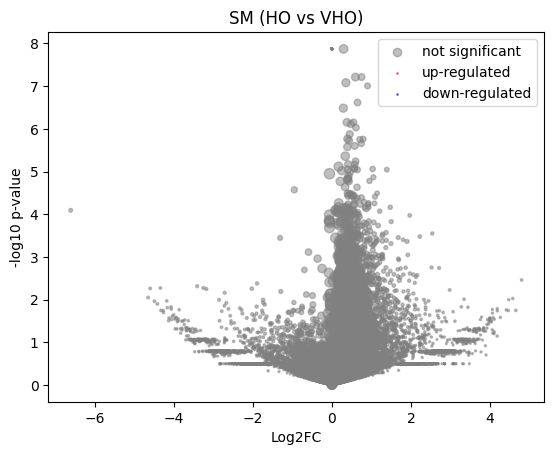

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


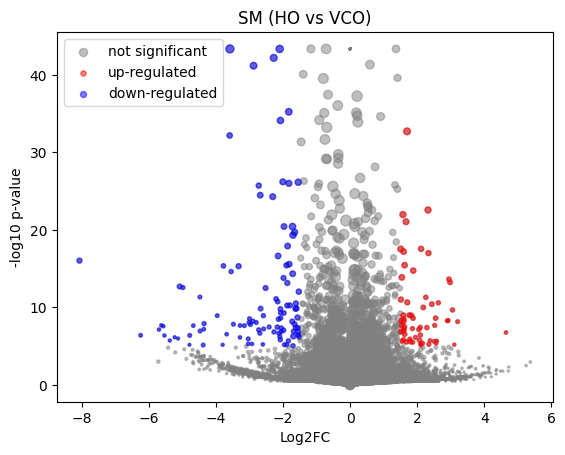

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


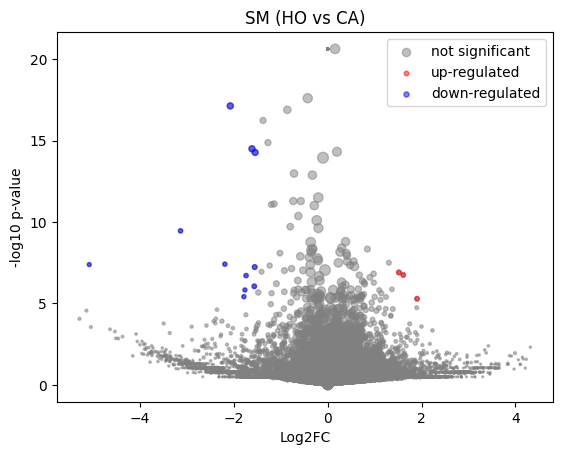

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


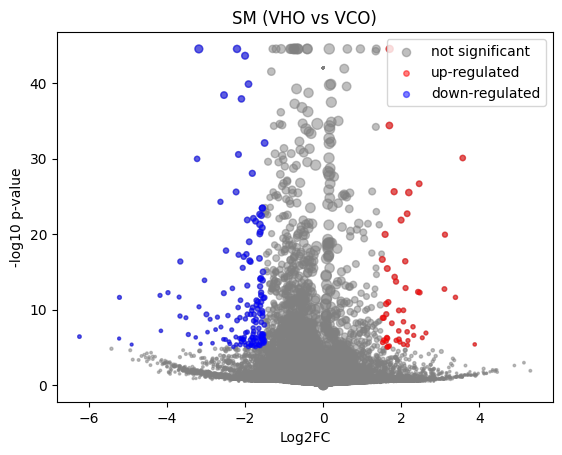

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


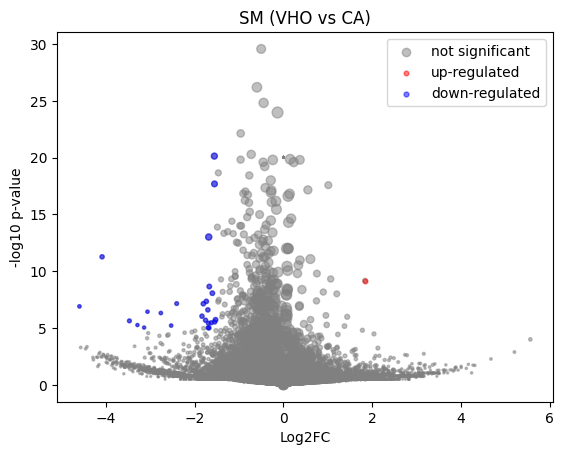

/tmp/ipykernel_722164/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


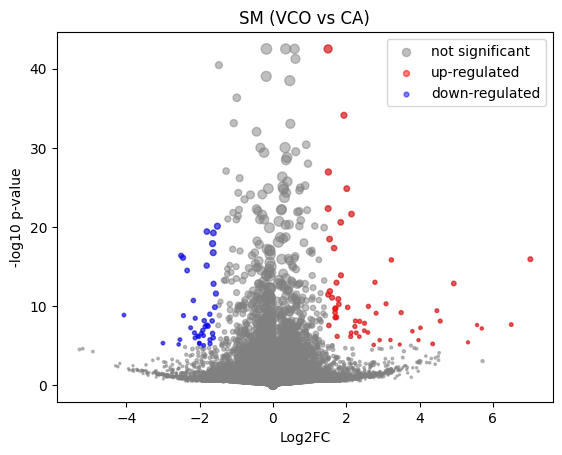

In [52]:
celltype = 'SM'
adata_list = ['VO', 'HO', 'VHO', 'VCO', 'CA']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

## 4. DE between subclusters

In [21]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/CM_subcluster
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/FB_subcluster
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/EN_subcluster

/tmp/ipykernel_3045190/2173370703.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


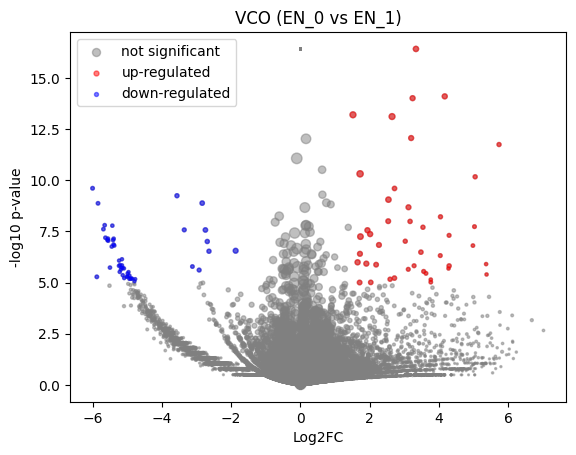

In [22]:
sample = 'VCO'
CM_subclusters = ['EN_0', 'EN_1']

for i in range(0, len(CM_subclusters)):
    for j in range(i+1, len(CM_subclusters)):
        subc1 = CM_subclusters[i]
        subc2 = CM_subclusters[j]
        volcano_plot2(adatas[sample], 
                      subc1, 
                      subc2, 
                      f"{sample} ({subc1} vs {subc2})", 
                      save=f"{WORK_DIR}/volcano/EN_subcluster/{sample}.{subc1}.{subc2}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/EN_subcluster/{sample}.{subc1}.{subc2}.tsv")

/tmp/ipykernel_3045190/2173370703.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


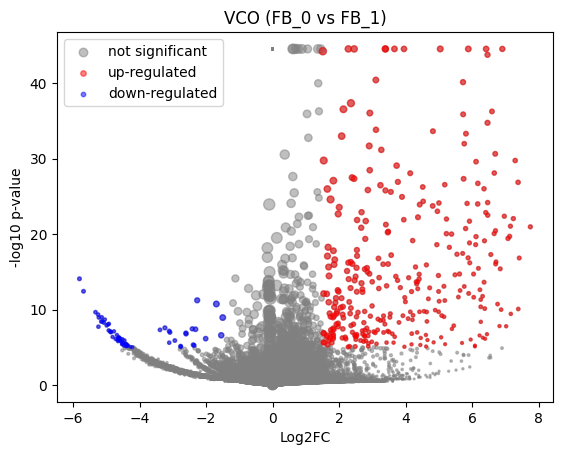

In [23]:
sample = 'VCO'
CM_subclusters = ['FB_0', 'FB_1']

for i in range(0, len(CM_subclusters)):
    for j in range(i+1, len(CM_subclusters)):
        subc1 = CM_subclusters[i]
        subc2 = CM_subclusters[j]
        volcano_plot2(adatas[sample], 
                      subc1, 
                      subc2, 
                      f"{sample} ({subc1} vs {subc2})", 
                      save=f"{WORK_DIR}/volcano/FB_subcluster/{sample}.{subc1}.{subc2}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/FB_subcluster/{sample}.{subc1}.{subc2}.tsv")

/tmp/ipykernel_3045190/2173370703.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


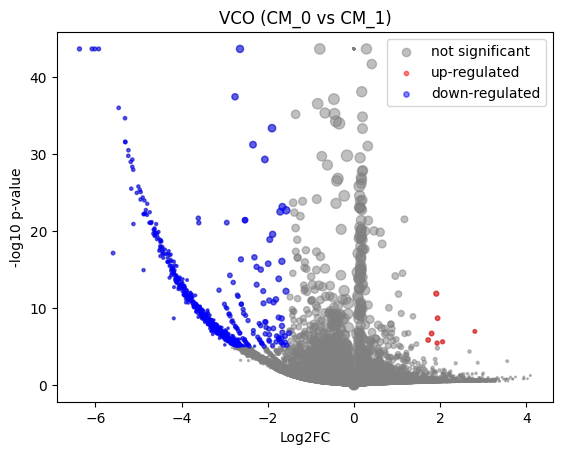

/tmp/ipykernel_3045190/2173370703.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


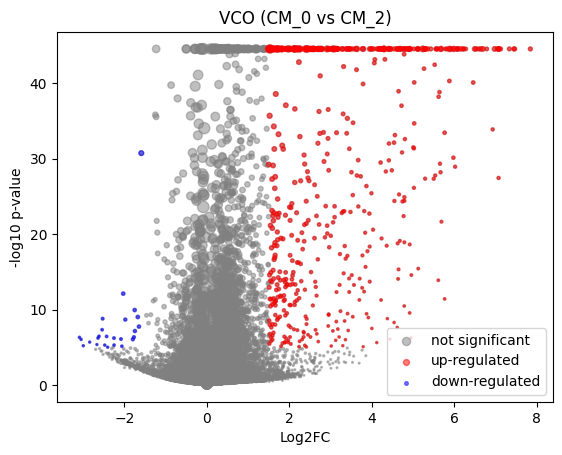

/tmp/ipykernel_3045190/2173370703.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


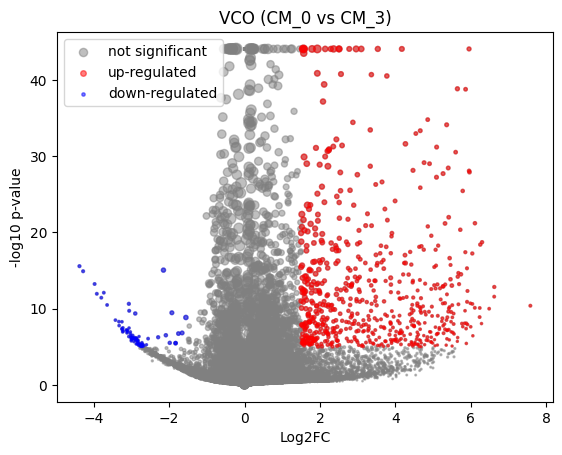

/tmp/ipykernel_3045190/2173370703.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


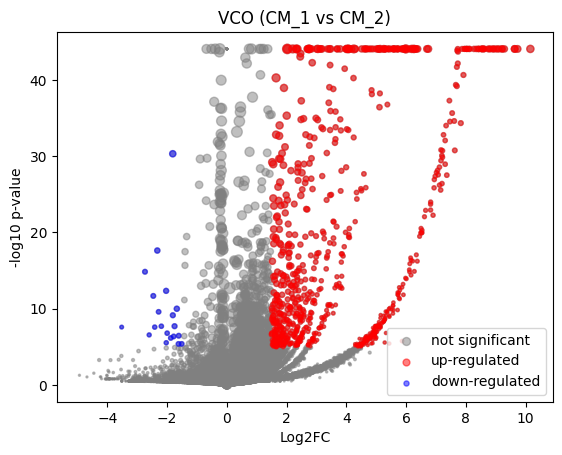

/tmp/ipykernel_3045190/2173370703.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


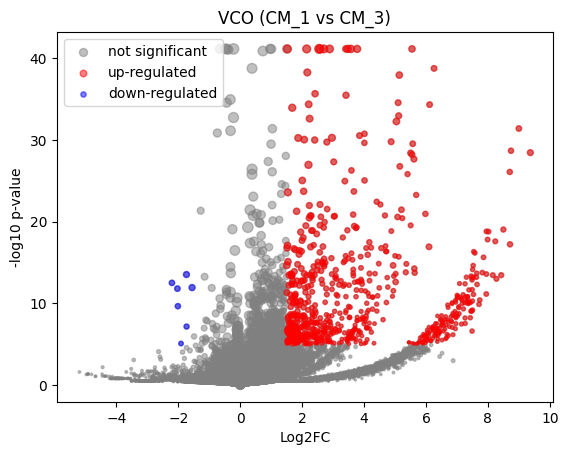

/tmp/ipykernel_3045190/2173370703.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


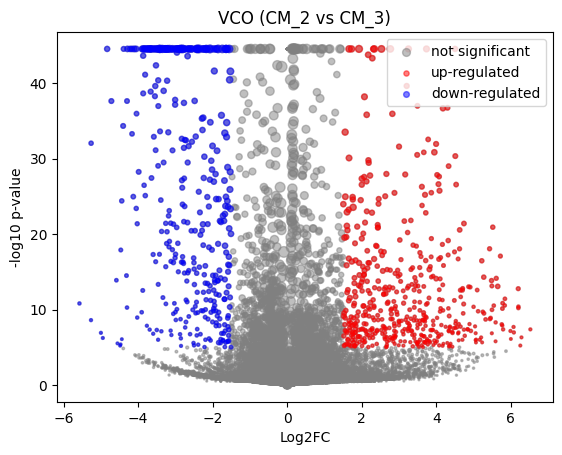

In [19]:
sample = 'VCO'
CM_subclusters = ['CM_0', 'CM_1', 'CM_2', 'CM_3']

for i in range(0, len(CM_subclusters)):
    for j in range(i+1, len(CM_subclusters)):
        subc1 = CM_subclusters[i]
        subc2 = CM_subclusters[j]
        volcano_plot2(adatas[sample], 
                      subc1, 
                      subc2, 
                      f"{sample} ({subc1} vs {subc2})", 
                      save=f"{WORK_DIR}/volcano/CM_subcluster/{sample}.{subc1}.{subc2}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/CM_subcluster/{sample}.{subc1}.{subc2}.tsv")

## 5. Velocity

In [17]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/velocity

In [2]:
# activate scVelo env for this

import scvelo as scv
import scanpy as sc
import matplotlib.pyplot as plt

Filtered out 26476 genes that are detected 20 counts (shared).
Normalized count data: spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_2519373/2575009813.py:12: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:07) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:03) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/192 cores)
    finished (0:00:34) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-pac

saving figure to file /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/velocity/VO.png


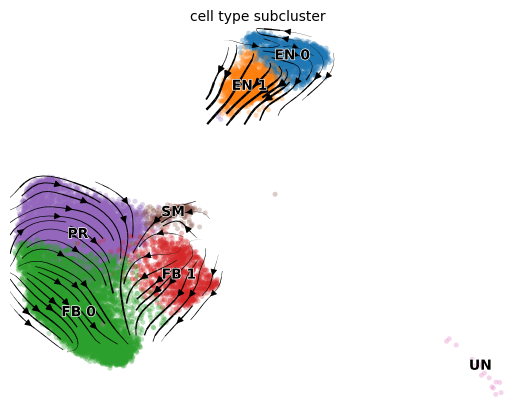

Filtered out 25915 genes that are detected 20 counts (shared).
Normalized count data: spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_2519373/2575009813.py:12: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:05) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:01) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/192 cores)
    finished (0:00:10) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-pac

saving figure to file /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/velocity/HO.png


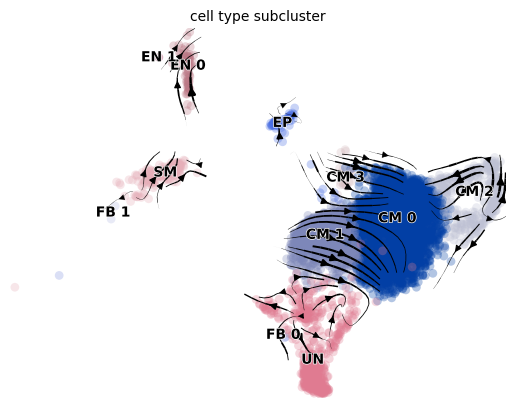

Filtered out 26132 genes that are detected 20 counts (shared).
Normalized count data: spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_2519373/2575009813.py:12: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:01) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:01) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/192 cores)
    finished (0:00:14) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-pac

saving figure to file /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/velocity/CA.png


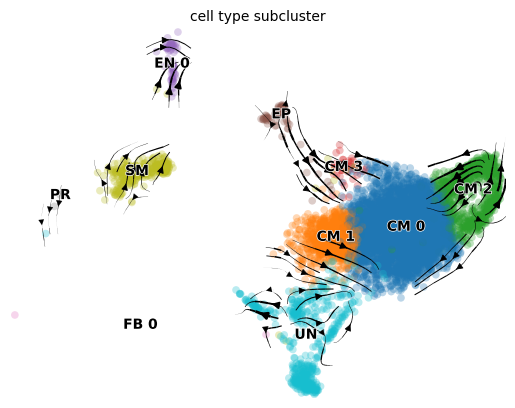

Filtered out 25995 genes that are detected 20 counts (shared).
Normalized count data: spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_2519373/2575009813.py:12: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:02) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:02) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/192 cores)
    finished (0:00:30) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-pac

saving figure to file /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/velocity/VHO.png


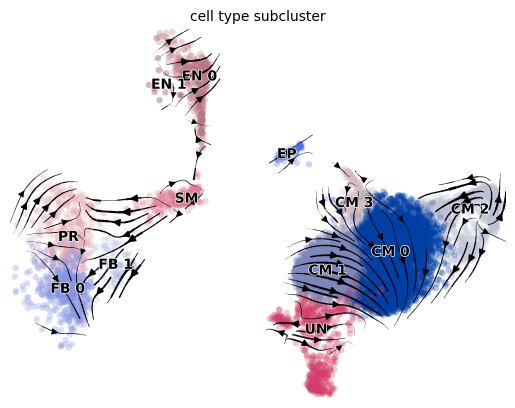

Filtered out 25872 genes that are detected 20 counts (shared).
Normalized count data: spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_2519373/2575009813.py:12: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:02) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:02) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/192 cores)
    finished (0:00:19) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/herbert/anaconda3/envs/scVelo/lib/python3.9/site-pac

saving figure to file /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/velocity/VCO.png


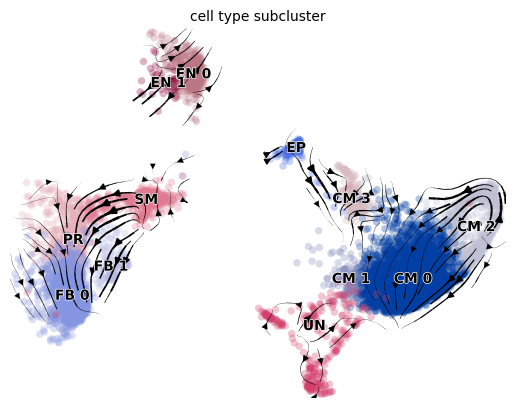

In [18]:
loom_file_names = ['BVO', 'HO', 'CM3O', 'BHO', 'CM3B']
adata_file_names = ['VO', 'HO', 'CA', 'VHO', 'VCO']

for i in range(0, 5):

    loom_file = f'/home/herbert/PyProjects/cocultured_organ/data/240603/SC160__{loom_file_names[i]}-JW-052224/SC160__{loom_file_names[i]}-JW-052224.loom'
    ldata = sc.read(loom_file, cache=True)
    adata = sc.read_h5ad(f'/home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/sample_recollect/{adata_file_names[i]}.h5ad')
    adata = scv.utils.merge(adata, ldata)

    scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
    scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
    scv.tl.velocity(adata)
    scv.tl.velocity_graph(adata)
    scv.pl.velocity_embedding_stream(adata, basis='umap', color='cell_type_subcluster', save=f"{WORK_DIR}/velocity/{adata_file_names[i]}.png")